## Computing the probability distribution of ring parameters from observed stellar density
### By Jorge I. Zuluaga, Pablo Agudelo, David Kipping

### Formulation of the problem

Using transity photometry of an exoplanet we have obtained the posterior probability distribution function (pdf) of the observed stellar density ($\rho_\mathrm{obs}$) of the host star. We also have estimations of the stellar mass $M_\star$ and radius $R_\star$ (mean values and errors), and therefore of the stellar true density $\rho_\mathrm{true}$ (a pdf).

Our goal is to determine the probability distribution function (pdf) of the planet and ring properties (size and orientation) that better explain the observed stellar density, provided the true stellar density.

### Available information

Information we assume it is known without any uncertainty:

- Planetary orbit eccentricity, $e_\mathrm{orb}$
- Planetart orbit inclination, $i_\mathrm{orb}$ or impact parameter $b$.
- Transit depth, $p$.
- Planet mass, $M_p$.

Information that are part of the transit photometry fitting procedure

- Planet orbit semimajor axis, $a_\mathrm{orb}$, which is normally expressed as a ratio $a_\mathrm{orb}/R_\star$
- Planet orbital period, $P_\mathrm{orb} = P_\mathrm{orb}(a,M_\star)$
- Ringless planet radius, $R_p^0 = (pR_\star^2)^{1/2}$.

Information that we know with errors or pdf:

- Posterior distribution of the observed stellar density, $p(\rho_\mathrm{obs})$.

- Stellar mass $M_\star$ and radius $R_\star$ are assumed to follow a simple (truncated) multivariate normal distribution function, $g(M_\star,R_\star) = N_{T}(\{\bar M_\star,\bar R_\star\};\Sigma)$.

- We assume that we know the mean observed value $\bar M_\star$ and $\bar R_\star$ and have an estimation of the standard deviadtion $\sigma_M$ and $\sigma_R$.

- For more complicated cases, for instance, when we have the pdf of the true stellar density $f(\rho_\star)$, we may play with the (unknown) correlation factor $\rho_{MR}$ to reconstruct $f(\rho_\star)$ from $g(M_\star,R_\star)$.

Information we want to determine:

- Planetary radius for a ringed planet, $R_p$. Units: meters. Potential range: [$R_p^\mathrm{min} = R_\oplus (M_p/M_\oplus)^{1/3}$, $R_p^\mathrm{max} = R_p^0$].
- Radius of the external ring, $f_e$ in units of $R_p$. $f_e=1$ means there are not rings. Units: adimensional. Potential range: [1,5].
- Inclination of the ring with respect to the orbit plane, $i_\mathrm{r}$. $i_\mathrm{r}=0$ means the rings are in the plane of the orbit. Units: degrees. Potential range: [0,90].
- Roll rotation of the ring, $\phi_\mathrm{r}$. $\phi_\mathrm{r}=0$ means that the node line of the ring are over the plane of the sky. Units: degrees. Potential range: [0,90].
- Normal optical depth of the ring, $\tau$. $\tau=0$ means the rings are transparent. Units: adimensional. Potential range: [0,5].

### Probability assumptions

Given a set of ringed-planet properties we can estimate the observed density:

$$
\rho_\mathrm{obs}(R_p,f_e,i_r,\phi_r;R_\star,M_\star)
$$

For simplicity we will assume that the probability of the planet parameters $q(R_p,f_e,i_r,\phi_r;R_\star,M_\star)$ is proportional to the observed stellar density, namely:

$$
q(R_p,f_e,i_r,\phi_r;R_\star,M_\star) \propto p(\rho_{obs}(R_p,f_e,i_r,\phi_r;R_\star,M_\star))
$$

**NOTE**: This is not strictly true. In fact, according to the coarea formula ([Wikipedia](https://en.wikipedia.org/wiki/Coarea_formula); [Negro, 2021](https://arxiv.org/pdf/2110.01441)) the relationship between both probability distributions will be:
$$
q(\mathbf{x})=\frac{p(\rho_\mathrm{obs}(\mathbf{x}))}{I(\rho_\mathrm{obs}(\mathbf{x}))}
$$
where he coarea factor is:
$$
I(\rho_\mathrm{obs}(\mathbf{x})) = \int_{L_{\rho_\mathrm{obs}(\mathbf{x})}} \frac{d S_{\mathbf{z}}}{\|\nabla \rho_\mathrm{obs}(\mathbf{z})\|}
$$
and $L_{\rho} = \{\mathbf{x} \in D \mid \rho_\mathrm{obs}(\mathbf{x})=\rho\}$ is a level set.

Estimating the coarea factor $I(\rho_\mathrm{obs}(\mathbf{x}))$ is not trivial due to the high dimensionality of the problem, we should remain that $\mathbf{x}:R_p,f_e,i_r,\phi_r,R_\star,M_\star$, and due to the fact that $\rho_\mathrm{obs}(\mathbf{x})$ is a numerical function that cannot be expressed in terms of elemental functions.  Although numerical procedures can be devised to estimate these factor, we have verified that it does not impact significantly generation of a random sample using the MCMC procedure. This is because in the Metropolis-Hasting algorithm, acceptance probability of a new sample $\mathbf{x}'$ will depend on the ratio:

$$
A\left(\mathbf{x} \rightarrow \mathbf{x}^{\prime}\right) = \frac{q(\mathbf{x'})}{q(\mathbf{x})} = \frac{p(\rho_\mathrm{obs}(\mathbf{x}'))}{p(\rho_\mathrm{obs}(\mathbf{x}))}
\frac{I(\rho_\mathrm{obs}(\mathbf{x}))}{I(\rho_\mathrm{obs}(\mathbf{x}'))}
$$

If we guarantee that the new sample $\mathbf{x}'$ is close to $\mathbf{x}$, and that the function $\rho_\mathrm{obs}(\mathbf{x})$ does not change significantly from one point to the other, then the ratio $I(\rho_\mathrm{obs}(\mathbf{x}))/I(\rho_\mathrm{obs}(\mathbf{x}'))$ is close to unit. We have performed numerical experiments to verify this.

### Method

For estimating $q(\cdots)$ we will generate using Markov Chain Monte Carlo (MCMC) a sample of the parameters $R_p,f_e,i_r,\phi_r,R_\star,M_\star$ and from their distribution we will get the desired posteriors.

Since we already know the distribution of $M_\star,R_\star$ our procedure will be divided in two steps.

1. Generate values of $R_\star$ and $M_\star$ than fulfills a given distribution.

2. Generate values of the planetary parameters set $\mathbf{p}:R_p,f_e,i_r,\phi_r$ according to the observed stellar density.

This is justified by the [law of total probability](https://en.wikipedia.org/wiki/Law_of_total_probability), that in our case give us the probability that a given planetary parameters set $\mathbf{p}$, irrespective the stellar properties:

$$
p(\mathbf{p}) = p(\mathbf{p}|R_\star^{(1)},M_\star^{(1)}) p(R_\star^{(1)},M_\star^{(1)}) + p(\mathbf{p}|R_\star^{(2)},M_\star^{(2)}) p(R_\star^{(2)},M_\star^{(2)}) + \cdots
$$
where $R_\star^{(i)},M_\star^{(i)}$ are discrete values of the stellar radius and mass.

### Algorithm

**Goal**: generate $N_s$ samples of the if the system parameters $R_p,f_e,i_r,\phi_r, R_\star,M_\star$.

1. Create a meshgrid of $M_\star$ and $R_\star$, $\mathrm{dim}(N_M\times N_R$), in the intervals $M_\star - 3\sigma_M, M_\star + 3\sigma_M$ and $R_\star - 3\sigma_R, R_\star + 3\sigma_R$. According to the resolution (number of rows and columns of the grid) we will have grid interspacings of $\Delta M_\star$ and $\Delta R_\star$.

2. Start with guess values of the planetary parameters: $R_p,f_e,i_r,\phi_r$.

3. Set the intervals of the planetary parameters:
   - [$R_p^\mathrm{min} = R_\oplus (M_p/M_\oplus)^{1/3}$, $R_p^\mathrm{max} = R_p^0$]
   - [$f_e^\mathrm{min} = 1$, $f_e^\mathrm{max} = 5$]
   - [$i_r^\mathrm{min} = 0$, $i_r^\mathrm{max} = 90$]
   - [$\phi_r^\mathrm{min} = 0$, $\phi_r^\mathrm{max} = 90$]

3. Set the value of the steps for the random walk of planetary parameter x. We can use the ansatz $\Delta x = \epsilon_x (x^\mathrm{max} - x^\mathrm{min})$, where $\epsilon_x$ is a free parameter that can be set wisely for each parameter. For instance: $\Delta R_p = 0.05 (R_p^\mathrm{max} - R_p^\mathrm{min})$, here $\epsilon_{Rp}=0.05$.

4. Create an empty sample list, $\mathbf{X}:[]$.

4. For each pair of values $M_\star$ and $R_\star$ in the grid:

   1. Calculate the number of samples for this point in the grid of $M_\star$ and $R_\star$: $N_p = N_s N_{T}(\{\bar M_\star,\bar R_\star\};\Sigma)\Delta M_\star \Delta R_\star$, where $N_T(\cdot,\cdot)$ is the truncated multivariate normal distribution.

   > **NOTE**: If $N_{T}(\{\bar M_\star,\bar R_\star\};\Sigma)$ is properly normalized in the grid, then when summing up the values of $N_p$ it will give $N_s$. Since the size of the grid is large enough (up to 3-sigma in width), using the non-truncated version will still work although the $N_p$ will not add-up to $N_s$

   2. Calculate the observed density for the latest value of the planetary and stellar parameters: $\rho_\mathrm{obs} = \rho_\mathrm{obs}(R_p,f_e,i_r,\phi_r;R_\star,M_\star)$ and the true density $\rho_\mathrm{true} = M_\star/(4/3\pi R_\star^3)$.

   3. Store the observed angles $i_\mathrm{eff}, \theta_\mathrm{eff}$.

   4. Calculate the probability of the observed density: $p = p(\rho_{obs})$

   5. For $i$ in $N_p$:

      1. Modify each planetary parameter using: $x' = x + \delta x$, where $\delta x \sim N(0,\Delta x)$ (generate a random gaussian number with mean 0 and standard deviation $\Delta x$).

      2. Calculate the observed density of the new set of planetary parameters: $\rho_\mathrm{obs}' = \rho_\mathrm{obs}(R_p',f_e',i_r',\phi_r';R_\star,M_\star)$.

      3. Store the observed angles $i_\mathrm{eff}', \theta_\mathrm{eff}'$.

      4. Calculate the probability of the new observed density $p' = p(\rho_{obs}')$

      5. Caclulate the acceptance ratio: $\alpha = \mathrm{min}(1,p'/p)$

      6. Generate a random number $u\sim \mathrm{Uniform}(0,1)$.

      7. If $u < \alpha$:
          
         1. Set the new accepted set of planetary parameters: $R_p,f_e,i_r,\phi_r, i_\mathrm{eff}, \theta_\mathrm{eff}= R_p',f_e',i_r',\phi_r',i_\mathrm{eff}', \theta_\mathrm{eff}'$.
          
         2. Set the observed stellar density: $\rho_\mathrm{obs} = \rho_\mathrm{obs}'$.

      7. Store the latest accepted set of planetary and stellar parameters: $\mathbf{X}.\mathrm{append}(R_p,f_e,i_r,\phi_r,i_\mathrm{eff}, \theta_\mathrm{eff},M_\star,R_\star,\rho_\mathrm{obs},\rho_\mathrm{true})$


### Observations

- As you may verify, if you take from the sample list, the number of times that a pair $M_\star, R_\star$ appears in the sample, they will follow the initial distribution of stellar mass and radius as desired.

- It could be interesting to store the sample in a matrix of samples $Q[\cdot,\cdot]$ in such a way that we can analyse how the planetary properties are distributed fixing a given stellar mass and radius. Thus for instance the $Q[0,0]$ sample will be the list of planetary parameters corresponding to the stellar mass and radius in the (0,0) position of the meshgrid.

## Implementation

Propeties of the system are available at: https://exoplanetarchive.ipac.caltech.edu/overview/Kepler-51


In [4]:
import os
# Check if running in Google Colab
if 'COLAB_GPU' in os.environ:
    # Clone the repository
    !git clone -b refactor https://github.com/seap-udea/GeoTrans

    # Install gdown if not already installed
    !pip install -Uq gdown

    # Download the file using gdown
    # https://drive.google.com/file/d/1ZWFfb7vBHe4RMdCO71z7XDg41fSo-dB9/view?usp=drive_link
    !gdown 1ZWFfb7vBHe4RMdCO71z7XDg41fSo-dB9

    # Unzip the downloaded file
    !unzip -oq Kepler-51-data.zip

Cloning into 'GeoTrans'...
remote: Enumerating objects: 231, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 231 (delta 21), reused 49 (delta 12), pack-reused 170 (from 1)
Receiving objects: 100% (231/231), 10.21 MiB | 16.29 MiB/s, done.
Resolving deltas: 100% (117/117), done.
/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1ZWFfb7vBHe4RMdCO71z7XDg41fSo-dB9
From (redirected): https://drive.google.com/uc?id=1ZWFfb7vBHe4RMdCO71z7XDg41fSo-dB9&confirm=t&uuid=e4bc4dcf-f8e0-42d6-beb2-b63b7f3dcdb9
To: /content/Kepler-51-data.zip
100% 415M/415M [00:08<00:00, 51.5MB/s]


In [20]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('GeoTrans')
from geotrans2 import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
import pickle

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Extract system properties

In [17]:
df = pd.read_csv('Kepler-51/GKTHCatalog_Table4.csv')
k51 = df[df['id_starname'] == 'kic11773022']
k51.iso_mass, k51.iso_mass_err1, k51.iso_mass_err2, k51.iso_rad, k51.iso_rad_err1, k51.iso_rad_err2

(1820    0.914664
 Name: iso_mass, dtype: float64,
 1820    0.041197
 Name: iso_mass_err1, dtype: float64,
 1820   -0.058405
 Name: iso_mass_err2, dtype: float64,
 1820    0.868832
 Name: iso_rad, dtype: float64,
 1820    0.031755
 Name: iso_rad_err1, dtype: float64,
 1820   -0.026073
 Name: iso_rad_err2, dtype: float64)

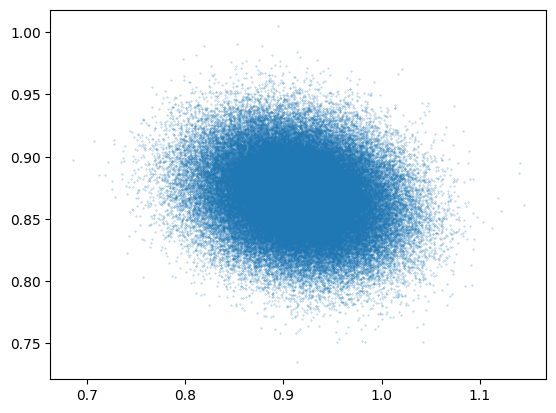

In [18]:
rho_true_sun = MSUN/(4/3 * np.pi * RSUN**3)

M_mean = k51.iso_mass.values[0]
R_mean = k51.iso_rad.values[0]
M_std = (k51.iso_mass_err1.values[0] + abs(k51.iso_mass_err2.values[0]))/2
R_std = (k51.iso_rad_err1.values[0] + abs(k51.iso_rad_err2.values[0]))/2

mean = [M_mean, R_mean]
rho_MR = -0.2
cov = [
    [M_std**2, rho_MR * M_std * R_std], 
    [rho_MR * M_std * R_std, R_std**2]
]

samples = np.random.multivariate_normal(mean, cov, int(1e5))

# Extract mass and radius samples
mass_samples = samples[:, 0]
radius_samples = samples[:, 1]

rho_samples = mass_samples / (radius_samples**3)*rho_true_sun

plt.scatter(mass_samples, radius_samples, s=0.1, alpha=0.5);

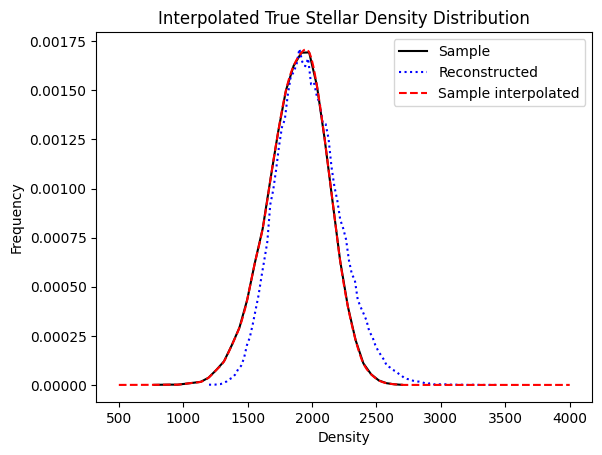

In [21]:
rho_trues = np.loadtxt('Kepler-51/berger2023_rhostar.dat')

# Histogram rho_true
bins = int(len(rho_trues)/3000)
hs,rhos = np.histogram(rho_trues, bins=bins, density=True)
rhos = 0.5*(rhos[1:] + rhos[:-1])

# Plot
plt.plot(rhos, hs, 'k-',label='Sample')

# Interpolated function
rho_true_fun = interp1d(rhos, hs, kind='cubic', fill_value=(0,0), bounds_error=False)
# Pickle the functions
with open('rho_true_fun.pkl', 'wb') as f:
    pickle.dump(rho_true_fun, f)

# Histogram rho_samples
bins = int(len(rho_samples)/1000)
hs,rhos = np.histogram(rho_samples, bins=bins, density=True)
rhos = 0.5*(rhos[1:] + rhos[:-1])
rho_sample_fun = interp1d(rhos, hs, kind='cubic', fill_value=(0,0), bounds_error=False)
plt.plot(rhos, hs, 'b:',label='Reconstructed')

# Interpolated/Extrapolated values
x = np.linspace(500, 4000, 400)
y = rho_true_fun(x)
plt.plot(x, y, 'r--',label='Sample interpolated')

# Decoration
plt.legend()
plt.xlabel('Density')
plt.ylabel('Frequency')
plt.title('Interpolated True Stellar Density Distribution')
plt.show()

#### Planetary properties

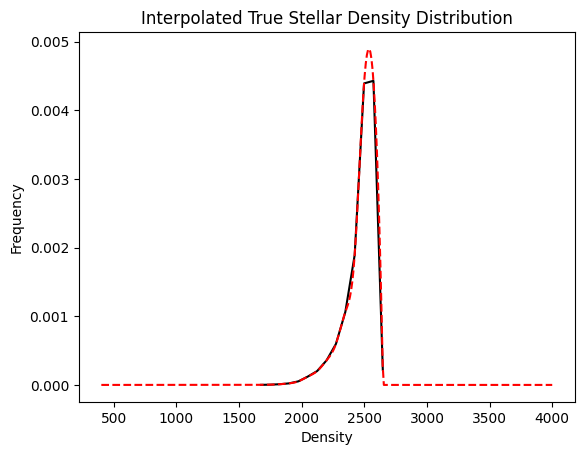

In [8]:
data = np.loadtxt('Kepler-51/Kepler-51b_45d/TTVplan3-post_equal_weights.dat')
rho_obs_b = data[:,1]

# Histogram
bins = int(len(rho_obs_b)/3000)
hs,rhos = np.histogram(rho_obs_b, bins=bins, density=True)
rhos = 0.5*(rhos[1:] + rhos[:-1])

# Interpolated function
rho_obs_fun = interp1d(rhos, hs, kind='cubic', fill_value=(0,0), bounds_error=False)

# Plot
plt.plot(rhos, hs, 'k-')

# Interpolated/Extrapolated values
x = np.linspace(400, 4000, 400)
y = rho_obs_fun(x)
plt.plot(x, y, 'r--')

# Decoration
plt.xlabel('Density')
plt.ylabel('Frequency')
plt.title('Interpolated True Stellar Density Distribution')
plt.show()

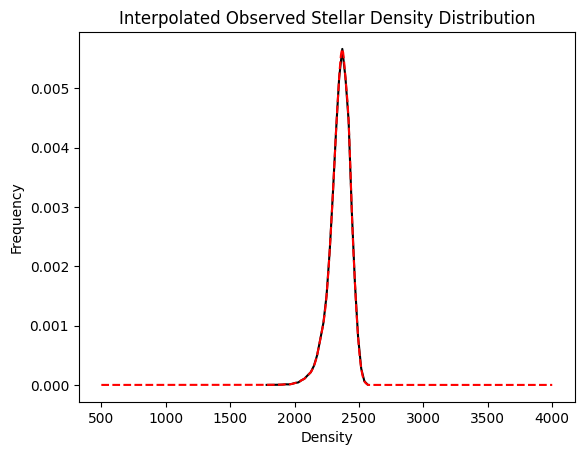

In [22]:
rho_obs_b = np.loadtxt('Kepler-51/Kepler-51b_45d/rhob_samples.dat')

# Histogram
bins = int(len(rho_obs_b)/3000)
hs,rhos = np.histogram(rho_obs_b, bins=bins, density=True)
rhos = 0.5*(rhos[1:] + rhos[:-1])

# Interpolated function
rho_obs_b_fun = interp1d(rhos, hs, kind='cubic', fill_value=(0,0), bounds_error=False)
with open('rho_obs_b_fun.pkl', 'wb') as f:
    pickle.dump(rho_obs_b_fun, f)

# Plot
plt.plot(rhos, hs, 'k-')

# Interpolated/Extrapolated values
x = np.linspace(500, 4000, 400)
y = rho_obs_b_fun(x)
plt.plot(x, y, 'r--')

# Decoration
plt.xlabel('Density')
plt.ylabel('Frequency')
plt.title('Interpolated Observed Stellar Density Distribution')
plt.show()

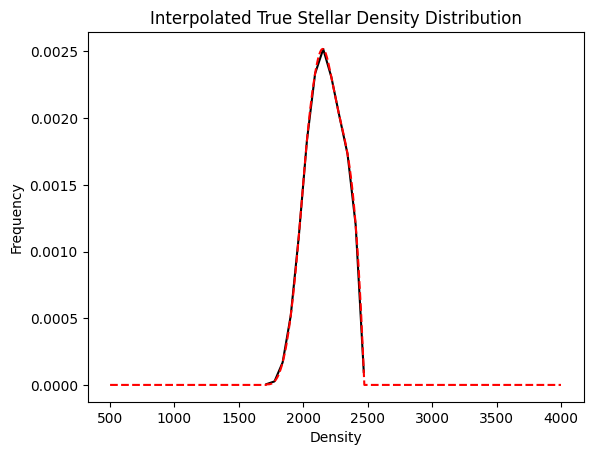

In [23]:
data = np.loadtxt('Kepler-51/Kepler-51c_130d/TTVplan-post_equal_weights.dat')
rho_obs_c = data[:,1]

# Histogram
bins = int(len(rho_obs_c)/3000)
hs,rhos = np.histogram(rho_obs_c, bins=bins, density=True)
rhos = 0.5*(rhos[1:] + rhos[:-1])

# Interpolated function
rho_obs_c_fun = interp1d(rhos, hs, kind='cubic', fill_value=(0,0), bounds_error=False)
with open('rho_obs_c_fun.pkl', 'wb') as f:
    pickle.dump(rho_obs_c_fun, f)

# Plot
plt.plot(rhos, hs, 'k-')

# Interpolated/Extrapolated values
x = np.linspace(500, 4000, 400)
y = rho_obs_c_fun(x)
plt.plot(x, y, 'r--')

# Decoration
plt.xlabel('Density')
plt.ylabel('Frequency')
plt.title('Interpolated True Stellar Density Distribution')
plt.show()

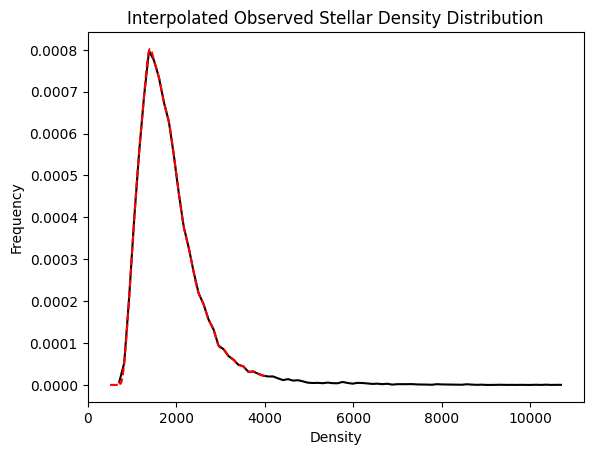

In [24]:
data = np.loadtxt('Kepler-51/Kepler-51d_85d/TTVplan-post_equal_weights.dat')
rho_obs_d = data[:,1]

# Histogram
bins = int(len(rho_obs_d)/500)
hs,rhos = np.histogram(rho_obs_d, bins=bins, density=True)
rhos = 0.5*(rhos[1:] + rhos[:-1])

# Interpolated function
rho_obs_d_fun = interp1d(rhos, hs, kind='cubic', fill_value=(0,0), bounds_error=False)
with open('rho_obs_d_fun.pkl', 'wb') as f:
    pickle.dump(rho_obs_d_fun, f)

# Plot
plt.plot(rhos, hs, 'k-')

# Interpolated/Extrapolated values
x = np.linspace(500, 4000, 400)
y = rho_obs_d_fun(x)
plt.plot(x, y, 'r--')

# Decoration
plt.xlabel('Density')
plt.ylabel('Frequency')
plt.title('Interpolated Observed Stellar Density Distribution')
plt.show()

### Load all densities

In [27]:
# Unpickle the functions
with open('rho_true_fun.pkl', 'rb') as f:
    rho_true_fun = pickle.load(f)

with open('rho_obs_b_fun.pkl', 'rb') as f:
    rho_obs_b_fun = pickle.load(f)

with open('rho_obs_c_fun.pkl', 'rb') as f:
    rho_obs_c_fun = pickle.load(f)

with open('rho_obs_d_fun.pkl', 'rb') as f:
    rho_obs_d_fun = pickle.load(f)

All densities

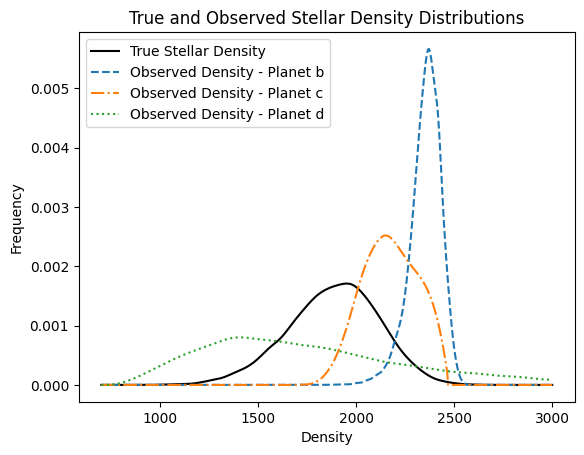

In [26]:
# Define the range for x-axis
x_range = np.linspace(700, 3000, 400)

# Plot rho_true_fun
plt.plot(x_range, rho_true_fun(x_range), label='True Stellar Density', color='black')

# Plot rho_obs_*_fun for each planet
plt.plot(x_range, rho_obs_b_fun(x_range), label='Observed Density - Planet b', linestyle='--')
plt.plot(x_range, rho_obs_c_fun(x_range), label='Observed Density - Planet c', linestyle='-.')
plt.plot(x_range, rho_obs_d_fun(x_range), label='Observed Density - Planet d', linestyle=':')

# Decoration
plt.xlabel('Density')
plt.ylabel('Frequency')
plt.title('True and Observed Stellar Density Distributions')
plt.legend()
plt.show()